This code bootstraps wind data by cluster

In [1]:
import numpy as np
import pandas as pd, os, datetime

# Statistical analysis
from typing import Sequence, Tuple, Optional
from joblib import Parallel, delayed
from scipy import stats
import math

import matplotlib.pyplot as plt

# Import the loader function
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

Dask dashboard: /proxy/8787/status


2026-01-27 08:39:28,558 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cee544f46277e03a913ec0f30b38a86e initialized by task ('shuffle-transfer-cee544f46277e03a913ec0f30b38a86e', 0) executed on worker tcp://127.0.0.1:34447
2026-01-27 08:39:38,251 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cee544f46277e03a913ec0f30b38a86e deactivated due to stimulus 'task-finished-1769463578.2489326'
2026-01-27 08:39:38,279 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d2bf34415c6f40f73dd94d7619c24bee initialized by task ('shuffle-transfer-d2bf34415c6f40f73dd94d7619c24bee', 1) executed on worker tcp://127.0.0.1:36421
2026-01-27 08:39:40,681 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d2bf34415c6f40f73dd94d7619c24bee deactivated due to stimulus 'task-finished-1769463580.3647907'


In [2]:
clust_map = pd.read_csv("data/preprocess/wind_profile_clusters.csv")

In [3]:
data, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="hourly",
    ftype=["Wind"],
    apply_remove_negatives=True,
    apply_remove_wind_zeros=True,
    apply_min_heatwave_days=True,
    min_heatwave_days_threshold=20,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.18 sec
Select group: 0.00 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:168: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp_pd_jittered = grp_pd.groupby(['lat', 'lon'], group_keys=False).apply(


Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 1.36 seconds
filter_and_clean: 0.02 seconds
type_conversion_and_dropna: 0.03 seconds
date_filter: 0.01 seconds
hw_tseries_filter: 9.45 seconds
aggregate_hourly: 0.03 seconds
jitter: 0.21 seconds
final_merge: 0.02 seconds
compute: 71.22 seconds
--- END REPORT ---

Process group: 87.34 sec

--- DEBUG: Calculated Heatwave Days per Generator ---
DUID
MUSSELR1    334
SAPHWF1     206
WRWF1       201
HALLWF2     187
HALLWF1     187
GUNNING1    178
WOODLWN1    171
LKBONNY2    168
GULLRWF1    164
NBHWF1      162
WATERLWF    161
CLEMGPWF    158
SNOWTWN1    157
LKBONNY3    157
BLUFF1      151
TARALGA1    150
MEWF1       143
BOCORWF1    126
BODWF1      122
STWF1       115
SNOWNTH1    109
OAKLAND1    108
COOPGWF1    103
BALDHWF1    101
MACARTH1     98
HDWF1        98
HDWF2        92
HDWF3        92
SNOWSTH1     89
MERCER01     84
GRANWF1      84
CROOKWF2     76
ARWF1        72
K

Append clusters to generation timeseries in tidy format

In [4]:
clust_map

,DUID,profiles,lat,lon,profile_name,profile_color
0,ARWF1,4,-37.238518,143.079431,No difference,#d62728
1,BALDHWF1,4,-38.790800,145.927700,No difference,#d62728
2,BLUFF1,4,-33.369331,138.982476,No difference,#d62728
3,BOCORWF1,1,-36.576955,149.125867,Daytime increase,#1f77b4
4,BODWF1,3,-32.414600,149.099795,Morning peak,#2ca02c
5,BULGANA1,3,-37.118103,142.960530,Morning peak,#2ca02c
6,CHYTWF1,4,-37.099382,145.267835,No difference,#d62728
7,CLEMGPWF,3,-33.508568,138.119175,Morning peak,#2ca02c
8,CNUNDAWF,1,-37.760253,140.403311,Daytime increase,#1f77b4
9,COOPGWF1,5,-26.733227,151.472270,All-day low,#9467bd


In [5]:
df = pd.merge(data, clust_map[['DUID','profiles','profile_name','profile_color']], on='DUID', how='left')
df = pd.merge(df,info[['DUID','station_name']], on='DUID', how='left').sort_values(['EHF_flag','profiles','DUID','time'])

Z-score normalise by cluster.

In [6]:
df['z_score'] = df.groupby('DUID')['TOTALMWh'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)
df

,DUID,time,TOTALMWh,TOTALCLEARED,AGCSTATUS,lat,lon,tas,EHF_val,HW_EHF_avg,...,date,fuel_source_primary,region,lat_jittered,lon_jittered,profiles,profile_name,profile_color,station_name,z_score
293522,BOCORWF1,2014-08-29 02:00:00+00:00,0.0,0.0,0,-36.63,149.09,279.182373,0.00000,NaN,...,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.596813,149.159298,1.0,Daytime increase,#1f77b4,Boco Rock Wind Farm,-0.92126
293523,BOCORWF1,2014-08-29 03:00:00+00:00,0.000833,0.0,0,-36.63,149.09,279.182373,0.00000,NaN,...,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.596813,149.159298,1.0,Daytime increase,#1f77b4,Boco Rock Wind Farm,-0.921242
293524,BOCORWF1,2014-08-29 04:00:00+00:00,0.0,0.0,0,-36.63,149.09,279.182373,0.00000,NaN,...,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.596813,149.159298,1.0,Daytime increase,#1f77b4,Boco Rock Wind Farm,-0.92126
293525,BOCORWF1,2014-08-29 05:00:00+00:00,0.0,0.0,0,-36.63,149.09,279.182373,0.00000,NaN,...,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.596813,149.159298,1.0,Daytime increase,#1f77b4,Boco Rock Wind Farm,-0.92126
293526,BOCORWF1,2014-08-29 07:00:00+00:00,0.0,0.0,0,-36.63,149.09,279.182373,0.00000,NaN,...,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.596813,149.159298,1.0,Daytime increase,#1f77b4,Boco Rock Wind Farm,-0.92126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456205,CATHROCK,2024-03-13 19:00:00+00:00,33.791666,34.275,0,-34.87,135.56,292.691406,0.81169,4.827326,...,2024-03-13 00:00:00+00:00,Wind,SA1,-34.864972,135.596634,NaN,NaN,NaN,Cathedral Rocks,0.80488
456206,CATHROCK,2024-03-13 20:00:00+00:00,39.266667,39.533333,0,-34.87,135.56,292.691406,0.81169,4.827326,...,2024-03-13 00:00:00+00:00,Wind,SA1,-34.864972,135.596634,NaN,NaN,NaN,Cathedral Rocks,1.066293
456207,CATHROCK,2024-03-13 21:00:00+00:00,44.05,43.675001,0,-34.87,135.56,292.691406,0.81169,4.827326,...,2024-03-13 00:00:00+00:00,Wind,SA1,-34.864972,135.596634,NaN,NaN,NaN,Cathedral Rocks,1.294681
456208,CATHROCK,2024-03-13 22:00:00+00:00,58.058333,57.991666,0,-34.87,135.56,292.691406,0.81169,4.827326,...,2024-03-13 00:00:00+00:00,Wind,SA1,-34.864972,135.596634,NaN,NaN,NaN,Cathedral Rocks,1.963532


In [7]:
def bootstrap_curve(
    X: np.ndarray,
    n_boot: int,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bootstrap mean and median daily curves with confidence intervals, batched for speed and memory.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (n_days, n_hours)
    n_boot : int
        Number of bootstrap samples
    batch_size : Optional[int]
        Number of bootstrap samples to process per batch. If None, chosen automatically.
    seed : int
        RNG seed for reproducibility

    Returns
    -------
    mean_curve : np.ndarray, shape (n_hours,)
    mean_lower : np.ndarray, shape (n_hours,)
    mean_upper : np.ndarray, shape (n_hours,)
    median_curve : np.ndarray, shape (n_hours,)
    median_lower : np.ndarray, shape (n_hours,)
    median_upper : np.ndarray, shape (n_hours,)
    """
    n_days, n_hours = X.shape
    curves_mean = np.empty((n_boot, n_hours), dtype=np.float64)
    curves_median = np.empty((n_boot, n_hours), dtype=np.float64)
    rng = np.random.default_rng(seed)

    # Choose a batch size that keeps memory reasonable
    if batch_size is None:
        # Aim for ~50–200 MB peak for the 3D array; adjust as needed
        # Each float64 ~8 bytes -> batch_size * n_days * n_hours * 8 bytes
        target_bytes = 100 * 1024 * 1024  # 100 MB
        approx_bs = max(1, int(target_bytes / (n_days * n_hours * 8)))
        batch_size = min(n_boot, max(100, approx_bs))

    out_start = 0
    while out_start < n_boot:
        k = min(batch_size, n_boot - out_start)
        # Indices: shape (k, n_days)
        idx = rng.integers(0, n_days, size=(k, n_days))
        # Samples: shape (k, n_days, n_hours)
        samples = X[idx]
        # Aggregate across days -> shape (k, n_hours)
        curves_mean[out_start:out_start + k] = samples.mean(axis=1)
        curves_median[out_start:out_start + k] = np.median(samples, axis=1)
        out_start += k

    # Compute mean and 95% CI across bootstrap replicates
    mean_curve = curves_mean.mean(axis=0)
    mean_lower = np.percentile(curves_mean, 2.5, axis=0)
    mean_upper = np.percentile(curves_mean, 97.5, axis=0)

    # Median curve is the median across bootstrap medians
    median_curve = np.median(curves_median, axis=0)
    median_lower = np.percentile(curves_median, 2.5, axis=0)
    median_upper = np.percentile(curves_median, 97.5, axis=0)

    return mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper

In [8]:
def process_group(name, gdf: pd.DataFrame, values: str = 'z_score', n_boot: int = 1000, batch_size: Optional[int] = None):
    """
    Compute bootstrapped curves for a single grouped DataFrame.
    Returns:
        name (group key), curves tuple, hour_labels (array)
    """
    gdf = gdf.copy()
    gdf['day'] = gdf['time'].dt.floor('D')
    gdf['hour'] = gdf['time'].dt.hour

    daily_matrix = (
        gdf.pivot_table(index='day', columns='hour', values=values)
           .dropna()
           .sort_index()
    )

    if daily_matrix.empty:
        hour_labels = np.array(sorted(gdf['hour'].unique()))
        n_hours = len(hour_labels)
        empty = np.full(n_hours, np.nan)
        return name, (empty, empty, empty, empty, empty, empty), hour_labels

    X = daily_matrix.to_numpy()
    curves = bootstrap_curve(X, n_boot=n_boot, batch_size=batch_size, seed=42)
    hour_labels = daily_matrix.columns.to_numpy()
    return name, curves, hour_labels

In [9]:
def compute_bootstrap_df_joblib(
    df: pd.DataFrame,
    values: str = 'z_score',
    n_boot: int = 1000,
    group_cols: Sequence[str] = ('cluster', 'DUID', 'EHF_flag'),
    n_jobs: int = -1,  # use all cores by default
    backend: str = 'loky',  # 'loky' for processes (robust in notebooks), or 'threading'
    prefer: Optional[str] = None,  # 'processes' or 'threads'
    batch_size: Optional[int] = None,
) -> pd.DataFrame:
    """
    Notebook-friendly parallel computation of bootstrapped curves using joblib.

    Parameters
    ----------
    df : pd.DataFrame
        Must include columns: 'time' (datetime-like), group_cols, and `values`.
    values : str
        Column name to aggregate (default 'z_score').
    n_boot : int
        Number of bootstrap samples.
    group_cols : Sequence[str]
        Grouping columns, e.g. ('cluster','DUID','EHF_flag') or ('cluster','EHF_flag').
    n_jobs : int
        Number of parallel workers. -1 means all available cores.
    backend : str
        'loky' for separate processes (better isolation), or 'threading'.
    prefer : Optional[str]
        Hint for joblib scheduler: 'processes' or 'threads'. Usually not needed.
    batch_size : Optional[int]
        Bootstrap batch size; see `bootstrap_curve`.

    Returns
    -------
    pd.DataFrame with columns:
        * group_cols...
        * hour
        * mean, mean_lower, mean_upper
        * median, median_lower, median_upper
    """
    needed = set(group_cols) | {'time', values}
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    grouped = df.groupby(list(group_cols), sort=False)

    # Build tasks
    tasks = ((name, gdf, values, n_boot, batch_size) for name, gdf in grouped)

    # Run in parallel
    results = Parallel(n_jobs=n_jobs, backend=backend, prefer=prefer)(
        delayed(process_group)(name, gdf, values, n_boot, batch_size)
        for (name, gdf, values, n_boot, batch_size) in tasks
    )

    # Assemble rows
    rows = []
    for name, curves, hour_labels in results:
        mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper = curves

        if isinstance(name, tuple):
            key_map = dict(zip(group_cols, name))
        else:
            key_map = {group_cols[0]: name}

        for i, hour in enumerate(hour_labels):
            rows.append({
                **key_map,
                'hour': int(hour),
                'mean': float(mean_curve[i]) if np.isfinite(mean_curve[i]) else np.nan,
                'mean_lower': float(mean_lower[i]) if np.isfinite(mean_lower[i]) else np.nan,
                'mean_upper': float(mean_upper[i]) if np.isfinite(mean_upper[i]) else np.nan,
                'median': float(median_curve[i]) if np.isfinite(median_curve[i]) else np.nan,
                'median_lower': float(median_lower[i]) if np.isfinite(median_lower[i]) else np.nan,
                'median_upper': float(median_upper[i]) if np.isfinite(median_upper[i]) else np.nan,
            })

    return pd.DataFrame(rows)

Here is where the grouping, value, and number of bootstraps is specified.

In [10]:
def bootstrap_diff(df, n_boot=1000, values='z_score'):
    hw = df[df["EHF_flag"] == 1][values].values
    bl = df[df["EHF_flag"] == 0][values].values

    bootstrap_differences = []
    
    for i in range(n_boot):
        # Resample with replacement from each dataset
        sample_hw = np.random.choice(hw, size=len(hw), replace=True)
        sample_bl = np.random.choice(bl, size=len(bl), replace=True)

        # Calculate the difference in means for the current bootstrap sample
        bootstrap_differences.append(sample_hw.mean() - sample_bl.mean())

    return bootstrap_differences

In [11]:
x = df.groupby('DUID')[['EHF_flag','z_score']].apply(bootstrap_diff, include_groups=True)

In [12]:
x

DUID
ARWF1       [-0.13619889098096935, -0.11304559086082908, -...
BALDHWF1    [-0.13459741531721234, -0.13058588616473252, -...
BLUFF1      [-0.11655809773328857, -0.11620883797791129, -...
BOCORWF1    [0.18730771494325696, 0.15736887046527775, 0.1...
BODWF1      [0.041634541031458784, 0.03265648345746196, 0....
BULGANA1    [-0.023560663383880496, -0.002200198183408008,...
CATHROCK    [0.45193293497798664, 0.46832866713596527, 0.4...
CHYTWF1     [-0.10624236741205917, -0.0769514336280438, -0...
CLEMGPWF    [0.014436317954379769, -0.000532973623639356, ...
CNUNDAWF    [0.044260543643887804, 0.13690345404565493, 0....
COOPGWF1    [-0.3763609435663692, -0.3791767730598138, -0....
CROOKWF2    [0.10901891415416741, 0.1283471909940731, 0.06...
CROWLWF1    [-0.10324386374259135, -0.12683172468246223, -...
CRURWF1     [-0.13852785123391984, -0.14329244161387872, -...
CTHLWF1     [-0.06672290220697674, -0.03595674606563195, -...
DULAWF1     [0.1697940384530035, 0.17353145675722179, 0.22...
ELA

In [13]:
df_results = compute_bootstrap_df_joblib(
    df,
    values='z_score',
    n_boot=10000,
    group_cols=('profiles', 'DUID', 'EHF_flag'),
    n_jobs=-1,
    backend='loky',
)

In [14]:
df_results = df_results.merge(clust_map[['DUID','profile_name']], on='DUID')
df_results = pd.merge(df_results,info[['DUID','station_name']], on='DUID', how='left')

In [15]:
def plot_all_clusters_faceted(df_results: pd.DataFrame, metric='mean'):
    """
    Plot mean/median curves with 95% CI for all clusters in a 2x3 faceted layout.
    Each facet shows all DUIDs within the cluster, split by EHF_flag.

    Parameters
    ----------
    df_results : pd.DataFrame
        Columns needed:
        ['cluster','DUID','EHF_flag','hour',
         'mean','mean_lower','mean_upper',
         'median','median_lower','median_upper']
    metric : str
        'mean' or 'median'
    """
    if metric not in ['mean', 'median']:
        raise ValueError("metric must be 'mean' or 'median'")

    # Determine up to 6 clusters (or all if <= 6)
    clusters = sorted(df_results['profiles'].unique())
    n = len(clusters)
    if n == 0:
        raise ValueError("No clusters found in df_results")

    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 3.8*nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    label_map = {0.0: "Baseline", 1.0: "Heatwave"}
    label_map_int = {0: "Baseline", 1: "Heatwave"}
    colors = ['blue', 'orange'] if metric == "mean" else ['green', 'red']

    # Plot each cluster in its own facet
    for ax_idx, cluster_name in enumerate(clusters[:nrows*ncols]):
        ax = axes[ax_idx]
        cluster_df = df_results[df_results['profiles'] == cluster_name].copy()
        duids = sorted(cluster_df['DUID'].unique())

        # Plot each DUID's curves by EHF_flag
        for duid in duids:
            sub = cluster_df[cluster_df['DUID'] == duid]
            hw_statuses = sorted(sub['EHF_flag'].unique())

            for i, status in enumerate(hw_statuses):
                status_df = sub[sub['EHF_flag'] == status].sort_values('hour')

                y = status_df[metric].values
                lower = status_df[f'{metric}_lower'].values
                upper = status_df[f'{metric}_upper'].values

                label = label_map.get(float(status), label_map_int.get(int(status), str(status)))
                ax.plot(status_df['hour'], y, color=colors[i % len(colors)], alpha=0.9, label=label)
                ax.fill_between(status_df['hour'], lower, upper, color=colors[i % len(colors)], alpha=0.18)

        ax.set_title(f"Cluster {cluster_name}")
        ax.set_xticks(range(0, 24))
        ax.grid(True, alpha=0.2)

    # Remove unused axes if clusters < 6
    for ax in axes[len(clusters):]:
        ax.remove()

    fig.suptitle(f'{metric.capitalize()} daily generation profiles with CI — All Clusters', y=0.98)
    fig.text(0.5, 0.04, 'Hour of Day', ha='center')
    fig.text(0.02, 0.5, 'Value', va='center', rotation='vertical')

    # Shared legend for EHF statuses (avoid duplicates)
    handles, labels = axes[0].get_legend_handles_labels()
    # Deduplicate labels while preserving order
    seen = set()
    uniq = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
    if uniq:
        fig.legend([h for h, _ in uniq], [l for _, l in uniq], title="EHF status",
                   loc='upper right', bbox_to_anchor=(0.98, 0.98))
    plt.tight_layout(rect=[0.03, 0.05, 0.98, 0.93])
    plt.show()


In [16]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_cluster_duids_with_ci(df_results: pd.DataFrame, cluster_name, metric='mean', ncols=3):
    """
    Plot mean/median curves with 95% CI for every DUID within a cluster,
    each DUID in its own subplot, split by EHF_flag.
    """
    if metric not in ['mean', 'median']:
        raise ValueError("metric must be 'mean' or 'median'")

    cluster_df = df_results[df_results['profiles'] == cluster_name].copy()
    if cluster_df.empty:
        raise ValueError(f"No data for cluster {cluster_name}")

    profile_name = cluster_df['profile_name'].iloc[0]

    duids = sorted(cluster_df['DUID'].unique())
    n = len(duids)
    nrows = math.ceil(n / ncols)

    label_map = {0.0: "No heatwave", 1.0: "Heatwave", 0: "No heatwave", 1: "Heatwave"}
    colors = ['blue', 'orange'] if metric == "mean" else ['green', 'red']

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.5 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=True
    )

    # Always treat axes as 1D iterable
    axes = np.atleast_1d(axes).flatten()

    for ax, duid in zip(axes, duids):
        sub = cluster_df[cluster_df['DUID'] == duid]
        name = sub['station_name'].iloc[0]

        for i, status in enumerate(sorted(sub['EHF_flag'].unique())):
            status_df = sub[sub['EHF_flag'] == status].sort_values('hour')

            y = status_df[metric].values
            lower = status_df[f'{metric}_lower'].values
            upper = status_df[f'{metric}_upper'].values

            label = label_map.get(status, str(status))

            ax.plot(
                status_df['hour'],
                y,
                color=colors[i % len(colors)],
                label=label
            )
            ax.fill_between(
                status_df['hour'],
                lower,
                upper,
                color=colors[i % len(colors)],
                alpha=0.25
            )

        ax.set_title(f"{name} ({duid})")
        ax.set_xticks(range(0, 24, 4))
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{int(x):02d}:00")
        )
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.grid(True, which='both', linestyle='--', alpha=0.5)

    # Remove unused axes
    for ax in axes[len(duids):]:
        ax.remove()

    fig.suptitle(
        f'{metric.capitalize()} daily generation profiles with confidence intervals — {profile_name}',
        y=0.97, size=16
    )
    fig.text(0.5, 0.02, 'Hour of Day', ha='center', size=16)
    fig.text(0.02, 0.5, 'Generation (z-score)', va='center', rotation='vertical', size=16)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="EHF status",
        title_fontsize=16,
        fontsize=14,
        loc='lower right',
        bbox_to_anchor=(0.9, 0.1)
    )

    plt.tight_layout(rect=[0.03, 0.05, 0.9, 0.95])
    plt.show()


In [17]:
# plot_cluster_duids_with_ci(df_results, cluster_name=1, metric='mean')
# plot_cluster_duids_with_ci(df_results, cluster_name=2, metric='mean', ncols=5)
# plot_cluster_duids_with_ci(df_results, cluster_name=3, metric='mean', ncols=5)
# plot_cluster_duids_with_ci(df_results, cluster_name=4, metric='mean', ncols=5)
# plot_cluster_duids_with_ci(df_results, cluster_name=5, metric='mean')
# plot_cluster_duids_with_ci(df_results, cluster_name=6, metric='mean')

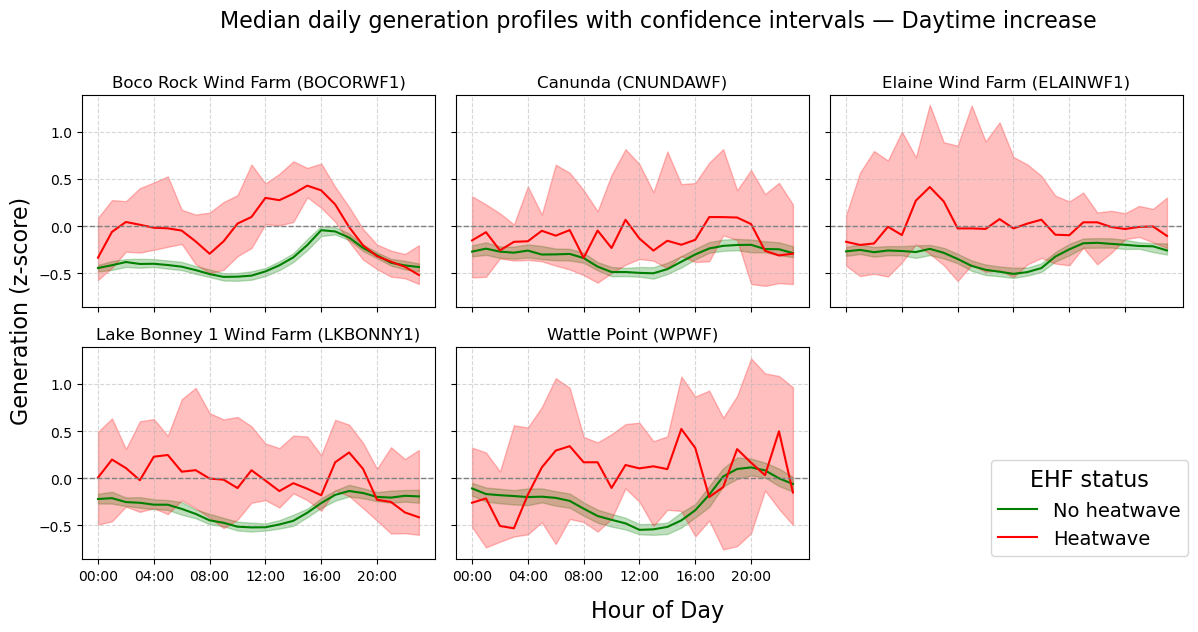

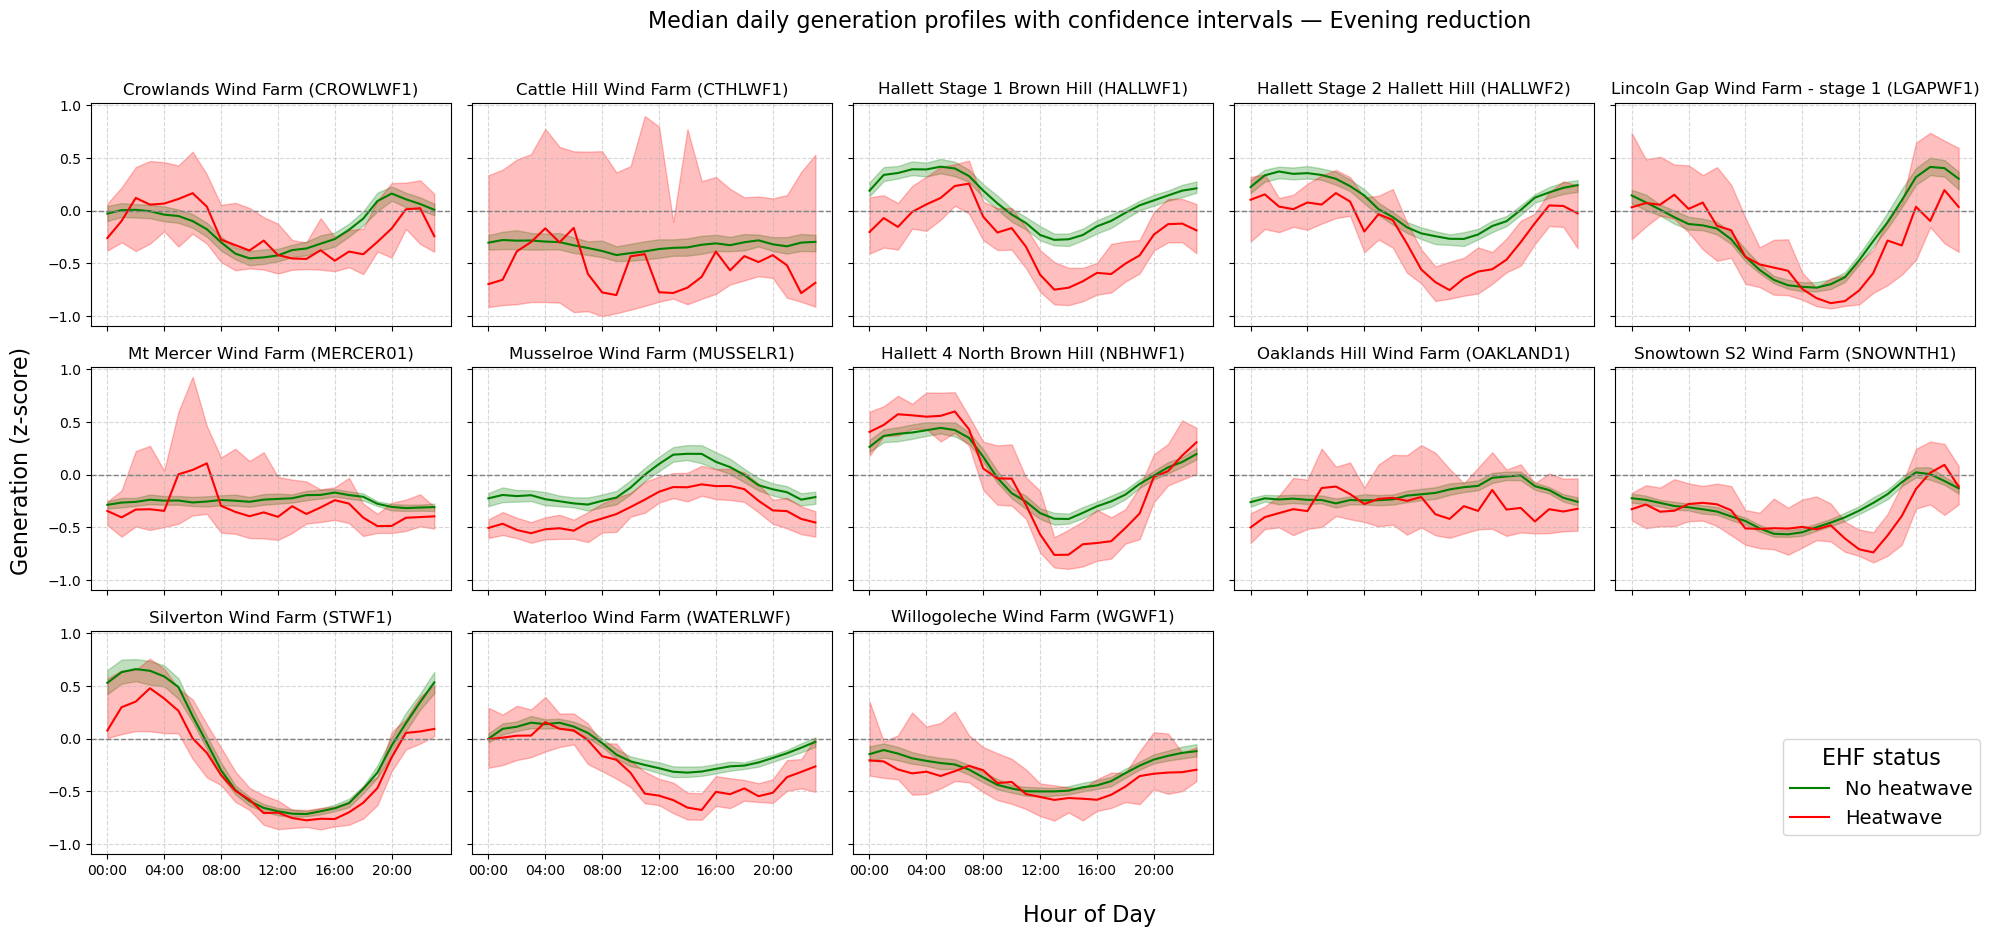

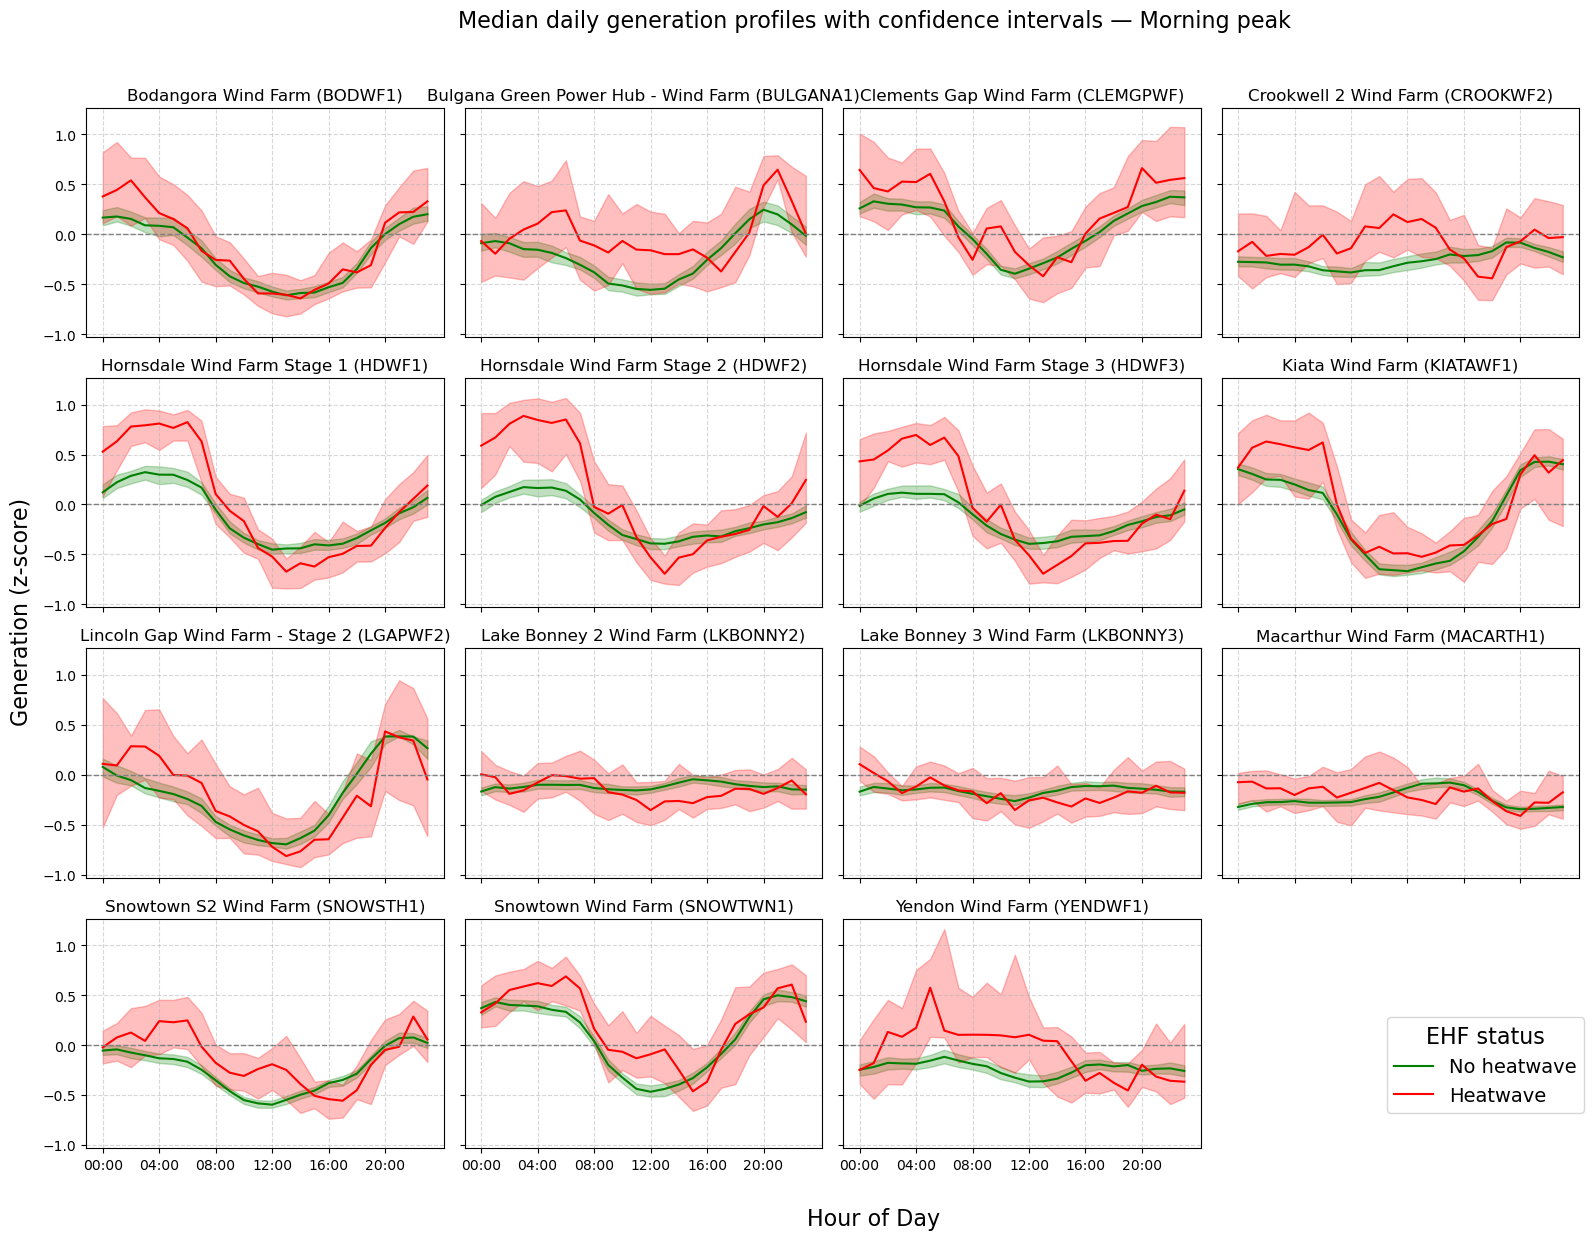

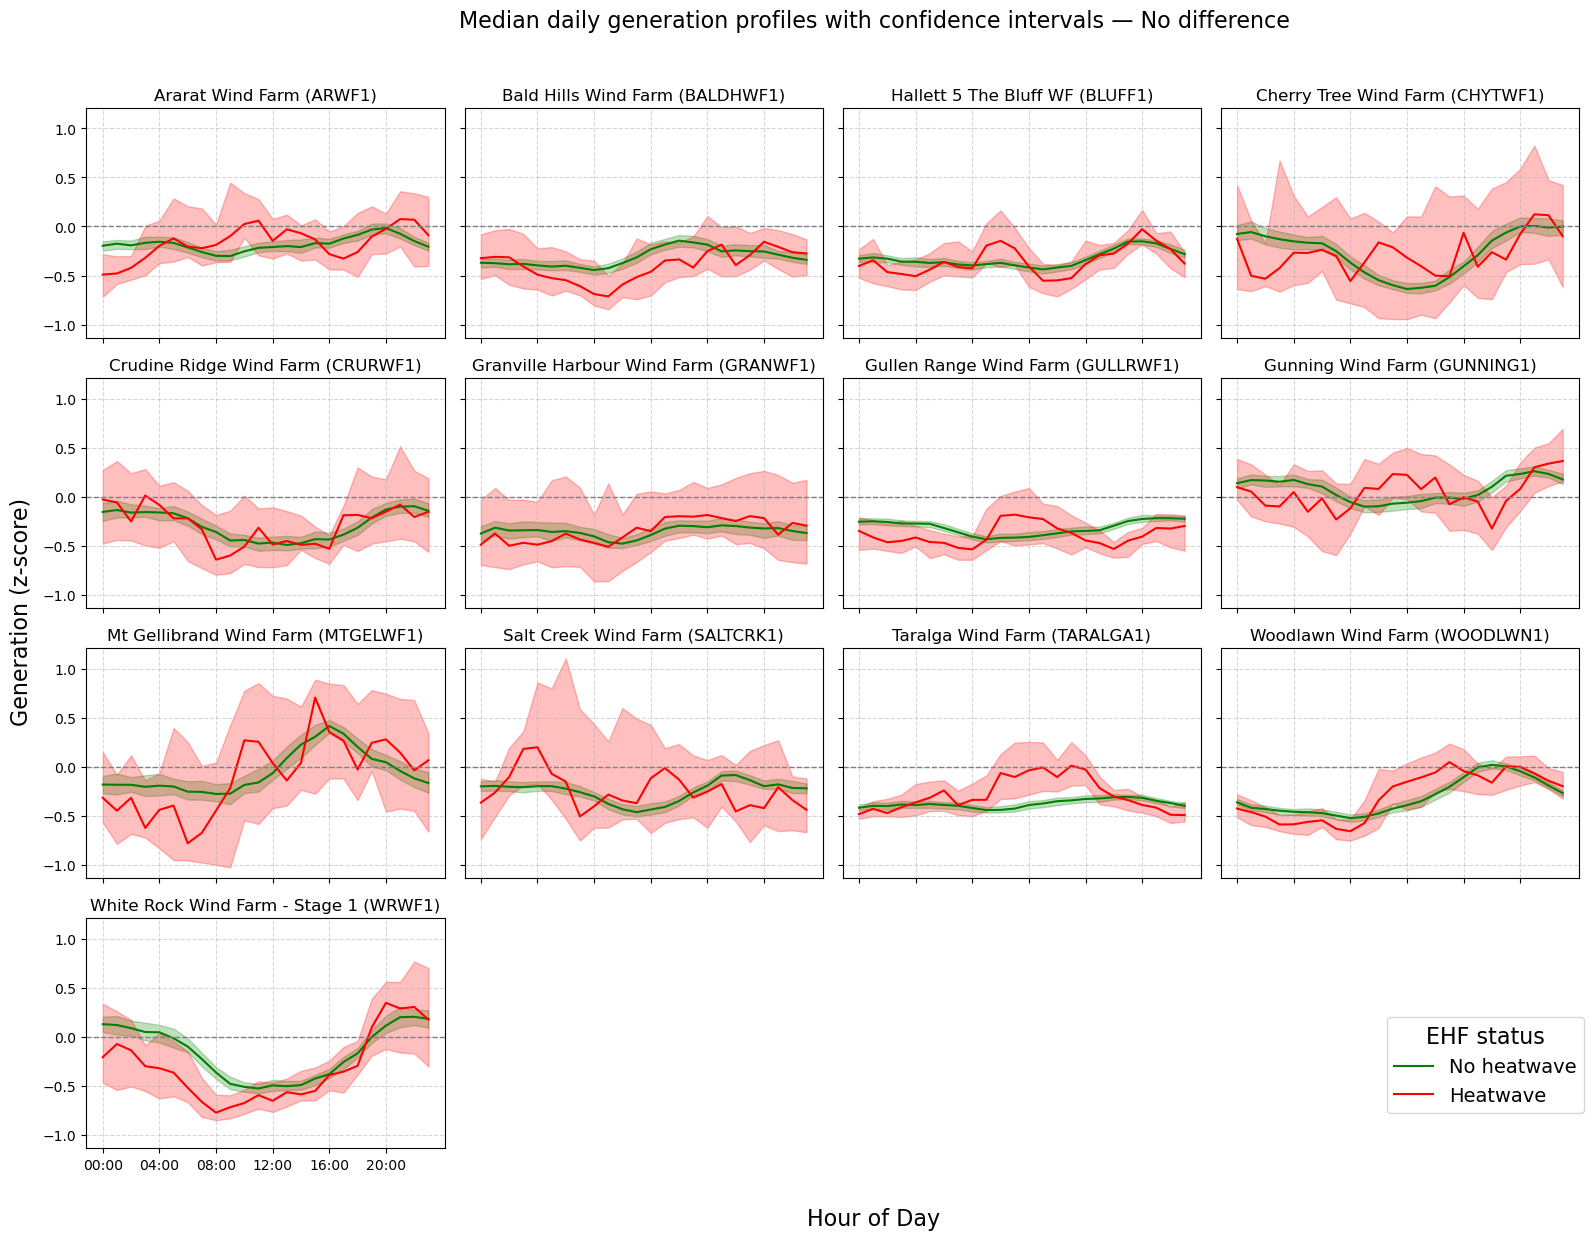

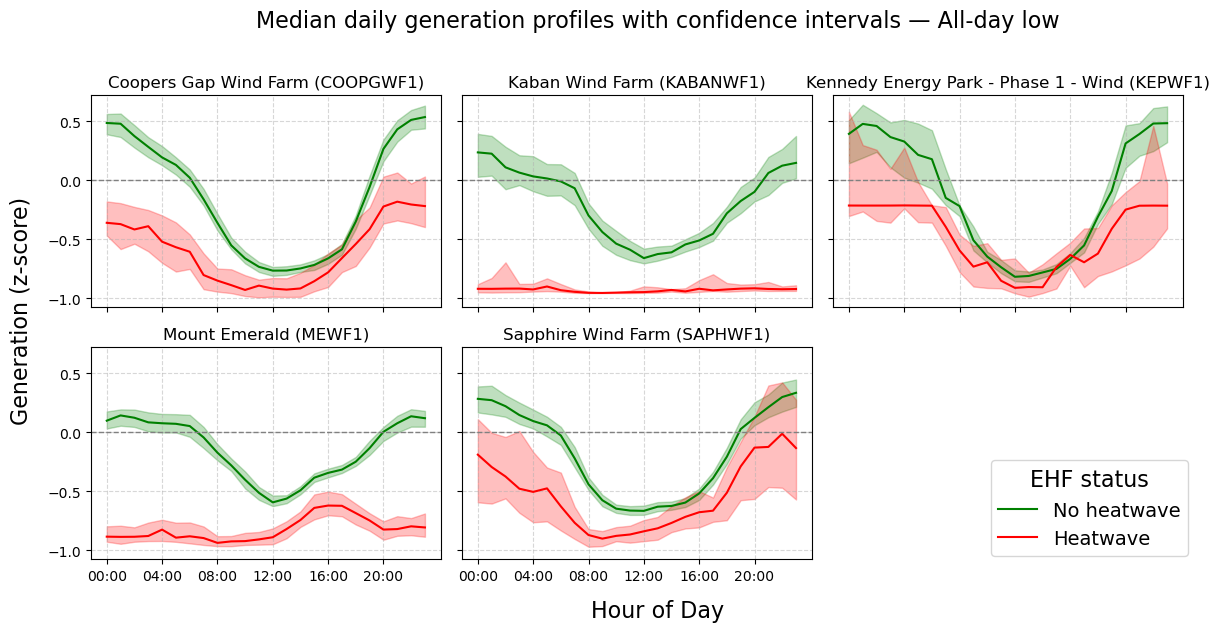

In [24]:
plot_cluster_duids_with_ci(df_results, cluster_name=1, metric='median')
plot_cluster_duids_with_ci(df_results, cluster_name=2, metric='median', ncols=5)
plot_cluster_duids_with_ci(df_results, cluster_name=3, metric='median', ncols=4)
plot_cluster_duids_with_ci(df_results, cluster_name=4, metric='median', ncols=4)
plot_cluster_duids_with_ci(df_results, cluster_name=5, metric='median')
# plot_cluster_duids_with_ci(df_results, cluster_name=6, metric='median')

In [19]:
df_results.to_csv("data/preprocess/DUID_curves.csv")